<a href="https://colab.research.google.com/github/ItumelengKocha/healthcare-rcm-analytics/blob/main/Healthcare_Python_Intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd

# Read your Excel file directly into a DataFrame
df_claims = pd.read_excel('/content/Healthcare Financial Performance & Claim Denial Analytics - Copy (1).xlsx', sheet_name='Data_Clean')

# Inspect the top 5 rows
df_claims.head()

,Claim ID,Provider ID,Patient ID,Date of Service,Procedure Code,Diagnosis Code,Billed Amount,Allowed Amount,Paid Amount,Insurance Type,Claim Status,Reason Code,Follow-up Required,AR Status,Outcome,Contractual Adjustment,Patient Responsibility,Collection Rate,Action Status
0,0HO1FSN4AP,126528997,7936697103,2024-08-07,99231,A02.1,304,218,203,Self-Pay,Paid,Incorrect billing information,Yes,Pending,Partially Paid,86,15,0.931193,Clean
1,9U86CI2P5A,6986719948,1547160031,2024-06-21,99213,A16.5,348,216,206,Medicare,Paid,Pre-existing condition,Yes,Open,Denied,132,10,0.953704,Follow Up
2,1QEU1AIDAU,1355108115,2611585318,2024-07-04,99213,A00.1,235,148,119,Commercial,Under Review,Duplicate claim,No,Denied,Denied,87,29,0.804054,Clean
3,WH7XDS8CEO,9991055906,7167948632,2024-05-26,99215,A18.6,112,79,69,Medicare,Denied,Authorization not obtained,No,Partially Paid,Denied,33,10,0.873418,Needs Appeals
4,M6OJEZ8KGI,7382167012,2140226267,2024-07-16,99238,A17.9,406,320,259,Medicare,Denied,Authorization not obtained,No,On Hold,Denied,86,61,0.809375,Needs Appeals


In [11]:
# 1. Total financial KPIs
total_billed = df_claims['Billed Amount'].sum()
total_paid = df_claims['Paid Amount'].sum()
overall_collection_rate = (total_paid / df_claims['Allowed Amount'].sum()) * 100

print(f"Total Billed Amount: ${total_billed:,.2f}")
print(f"Total Paid Amount:   ${total_paid:,.2f}")
print(f"Net Collection Rate: {overall_collection_rate:.2f}%\n")

# 2. Performance breakdown by Insurance Type
print("=== Performance by Payer ===")
payer_summary = df_claims.groupby('Insurance Type')[['Billed Amount', 'Paid Amount']].sum()
payer_summary['Net Collection Rate %'] = (payer_summary['Paid Amount'] / df_claims.groupby('Insurance Type')['Allowed Amount'].sum()) * 100
print(payer_summary.round(2))

# 3. Top Denial Reasons
print("\n=== Top Denial Reasons by Financial Exposure ===")
denied_claims = df_claims[df_claims['Outcome'] == 'Denied']
denial_summary = denied_claims.groupby('Reason Code')['Billed Amount'].agg(['count', 'sum']).rename(columns={'count': 'Denied Count', 'sum': 'Total Denied Billed'}).sort_values(by='Total Denied Billed', ascending=False)
denial_summary# 1. Total financial KPIs
total_billed = df_claims['Billed Amount'].sum()
total_paid = df_claims['Paid Amount'].sum()
overall_collection_rate = (total_paid / df_claims['Allowed Amount'].sum()) * 100

print(f"Total Billed Amount: ${total_billed:,.2f}")
print(f"Total Paid Amount:   ${total_paid:,.2f}")
print(f"Net Collection Rate: {overall_collection_rate:.2f}%\n")

# 2. Performance breakdown by Insurance Type
print("=== Performance by Payer ===")
payer_summary = df_claims.groupby('Insurance Type')[['Billed Amount', 'Paid Amount']].sum()
payer_summary['Net Collection Rate %'] = (payer_summary['Paid Amount'] / df_claims.groupby('Insurance Type')['Allowed Amount'].sum()) * 100
print(payer_summary.round(2))

# 3. Top Denial Reasons
print("\n=== Top Denial Reasons by Financial Exposure ===")
denied_claims = df_claims[df_claims['Outcome'] == 'Denied']
denial_summary = denied_claims.groupby('Reason Code')['Billed Amount'].agg(['count', 'sum']).rename(columns={'count': 'Denied Count', 'sum': 'Total Denied Billed'}).sort_values(by='Total Denied Billed', ascending=False)
denial_summary

Total Billed Amount: $297,191.00
Total Paid Amount:   $200,754.00
Net Collection Rate: 89.98%

=== Performance by Payer ===
                Billed Amount  Paid Amount  Net Collection Rate %
Insurance Type                                                   
Commercial              78520        53165                  90.18
Medicaid                78094        53177                  90.43
Medicare                66052        44156                  89.77
Self-Pay                74525        50256                  89.48

=== Top Denial Reasons by Financial Exposure ===
Total Billed Amount: $297,191.00
Total Paid Amount:   $200,754.00
Net Collection Rate: 89.98%

=== Performance by Payer ===
                Billed Amount  Paid Amount  Net Collection Rate %
Insurance Type                                                   
Commercial              78520        53165                  90.18
Medicaid                78094        53177                  90.43
Medicare                66052        44156

,Denied Count,Total Denied Billed
Reason Code,,
Incorrect billing information,52,16740
Lack of medical necessity,38,12157
Service not covered,43,12093
Patient eligibility issues,45,11672
Duplicate claim,41,11631
Pre-existing condition,42,11456
Missing documentation,37,11353
Authorization not obtained,33,9055


/tmp/ipykernel_1989/1761907153.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


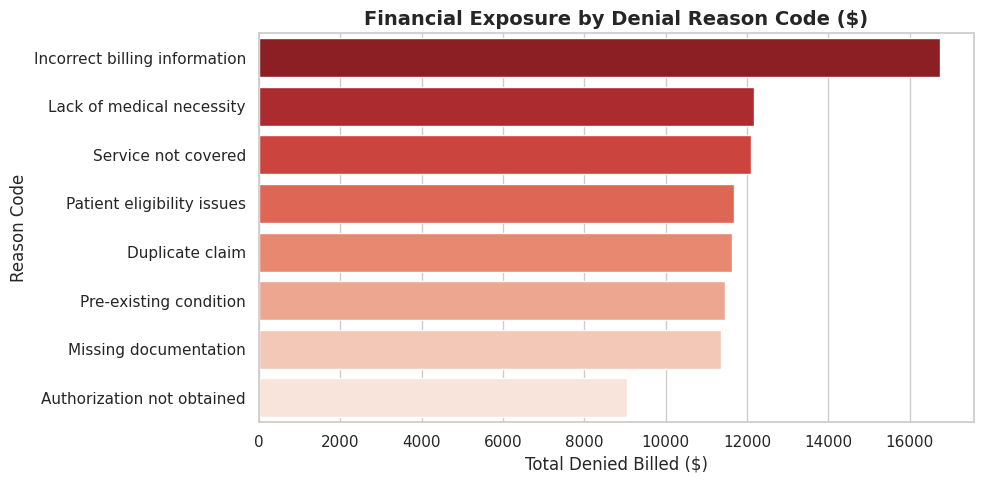

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean aesthetic style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# Plot top denial reasons by financial loss
sns.barplot(
    data=denial_summary.reset_index(),
    x='Total Denied Billed',
    y='Reason Code',
    palette='Reds_r'
)

plt.title('Financial Exposure by Denial Reason Code ($)', fontsize=14, fontweight='bold')
plt.xlabel('Total Denied Billed ($)', fontsize=12)
plt.ylabel('Reason Code', fontsize=12)
plt.tight_layout()

# Render chart directly in notebook
plt.show()